In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Data Exploration and Cleaning
# Load the dataset into a Pandas DataFrame and display the first 5 rows.

data = pd.read_csv("online_retail_sales_Large.csv")
data.head()

,Order_ID,Customer_ID,Order_Date,Product,Category,Quantity,Unit_Price,Payment_Method,Order_Status,City,Total_Amount
0,1,8270,2023-09-10,Headphones,Home Appliances,11,582.55,Cash,Completed,Hyderabad,6408.05
1,2,1860,2023-03-14,Laptop,Accessories,8,1635.00,PayPal,Completed,Hyderabad,13080.00
2,3,6390,2023-08-02,Headphones,Electronics,6,877.67,UPI,Completed,Pune,5266.02
3,4,6191,2024-01-14,TV,Accessories,9,2237.20,Credit Card,Completed,Pune,20134.80
4,5,6734,2023-10-26,Laptop,Accessories,7,1359.89,Credit Card,Completed,Mumbai,9519.23


In [3]:
# Check the dataset shape, column names, data types, and summary statistics.

print("Dataset shape: \n",data.shape)
print("column names: \n",data.columns.to_list())
print("Data Types: \n",data.dtypes)
print("summary statistics :\n",data.describe())


Dataset shape: 
 (50000, 11)
column names: 
 ['Order_ID', 'Customer_ID', 'Order_Date', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Payment_Method', 'Order_Status', 'City', 'Total_Amount']
Data Types: 
 Order_ID            int64
Customer_ID         int64
Order_Date         object
Product            object
Category           object
Quantity            int64
Unit_Price        float64
Payment_Method     object
Order_Status       object
City               object
Total_Amount      float64
dtype: object
summary statistics :
            Order_ID   Customer_ID      Quantity    Unit_Price  Total_Amount
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000
mean   25000.500000   5494.083720     12.493440   1259.940694  15776.022701
std    14433.901067   2601.545347      6.901944    715.936278  13461.642349
min        1.000000   1000.000000      1.000000     20.010000     22.340000
25%    12500.750000   3232.750000      6.000000    639.095000   4619.632500
50%    25000.5

In [4]:
# Identify missing values in each column.
print(data.isnull().sum())

Order_ID          0
Customer_ID       0
Order_Date        0
Product           0
Category          0
Quantity          0
Unit_Price        0
Payment_Method    0
Order_Status      0
City              0
Total_Amount      0
dtype: int64


In [5]:
# Handle missing values appropriately:
# Numerical columns: fill with mean or median.
# Categorical columns: fill with mode or drop.

data['Product'] = data['Product'].fillna('Unkown')
data['Unit_Price'] = data['Unit_Price'].fillna(data['Unit_Price'].median())

In [6]:
# Convert Order_Date into datetime format.
data['Order_Date'] = pd.to_datetime(data['Order_Date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        50000 non-null  int64         
 1   Customer_ID     50000 non-null  int64         
 2   Order_Date      50000 non-null  datetime64[ns]
 3   Product         50000 non-null  object        
 4   Category        50000 non-null  object        
 5   Quantity        50000 non-null  int64         
 6   Unit_Price      50000 non-null  float64       
 7   Payment_Method  50000 non-null  object        
 8   Order_Status    50000 non-null  object        
 9   City            50000 non-null  object        
 10  Total_Amount    50000 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 4.2+ MB


In [7]:
# Extract Year, Month, and Day from Order_Date into new columns.
data['Day'] = data['Order_Date'].dt.day
data['Month'] = data['Order_Date'].dt.month
data['Year'] = data['Order_Date'].dt.year
data.head()

,Order_ID,Customer_ID,Order_Date,Product,Category,Quantity,Unit_Price,Payment_Method,Order_Status,City,Total_Amount,Day,Month,Year
0,1,8270,2023-09-10,Headphones,Home Appliances,11,582.55,Cash,Completed,Hyderabad,6408.05,10,9,2023
1,2,1860,2023-03-14,Laptop,Accessories,8,1635.00,PayPal,Completed,Hyderabad,13080.00,14,3,2023
2,3,6390,2023-08-02,Headphones,Electronics,6,877.67,UPI,Completed,Pune,5266.02,2,8,2023
3,4,6191,2024-01-14,TV,Accessories,9,2237.20,Credit Card,Completed,Pune,20134.80,14,1,2024
4,5,6734,2023-10-26,Laptop,Accessories,7,1359.89,Credit Card,Completed,Mumbai,9519.23,26,10,2023


In [8]:
# 2. Data Selection and Filtering
# Retrieve all orders placed in March 2024.
all_order_march_2024 = data[(data['Month']==3) & (data['Year']==2024)]
all_order_march_2024.head(8)

,Order_ID,Customer_ID,Order_Date,Product,Category,Quantity,Unit_Price,Payment_Method,Order_Status,City,Total_Amount,Day,Month,Year
32,33,2267,2024-03-04,Laptop,Clothing,6,1892.98,UPI,Completed,Hyderabad,11357.88,4,3,2024
34,35,4556,2024-03-20,TV,Accessories,13,691.15,Cash,Returned,Bangalore,8984.95,20,3,2024
36,37,9838,2024-03-29,TV,Home Appliances,9,1138.31,UPI,Completed,Chennai,10244.79,29,3,2024
64,65,7439,2024-03-20,Shoes,Accessories,10,2078.13,PayPal,Completed,Hyderabad,20781.30,20,3,2024
82,83,3027,2024-03-29,Mobile,Accessories,18,56.06,Cash,Completed,Hyderabad,1009.08,29,3,2024
95,96,8215,2024-03-25,Laptop,Electronics,16,113.54,Debit Card,Completed,Bangalore,1816.64,25,3,2024
125,126,7892,2024-03-11,TV,Accessories,12,1777.17,Cash,Completed,Pune,21326.04,11,3,2024
135,136,6450,2024-03-02,Camera,Home Appliances,15,1222.36,PayPal,Completed,Kolkata,18335.40,2,3,2024


In [9]:
# Find all orders where:
# Total_Amount > 10000
# Category is Electronics.
category_electronic_totalAmount_10000 =  data[(data['Category']=='Electronics') & (data['Total_Amount'] > 10000)]
category_electronic_totalAmount_10000.head()


,Order_ID,Customer_ID,Order_Date,Product,Category,Quantity,Unit_Price,Payment_Method,Order_Status,City,Total_Amount,Day,Month,Year
18,19,5555,2023-08-22,Mobile,Electronics,10,2478.51,PayPal,Completed,Bangalore,24785.10,22,8,2023
23,24,8849,2023-08-17,TV,Electronics,19,967.10,PayPal,Cancelled,Bangalore,18374.90,17,8,2023
30,31,2899,2024-07-29,Camera,Electronics,22,2015.96,UPI,Cancelled,Pune,44351.12,29,7,2024
40,41,8513,2024-12-15,Camera,Electronics,19,2336.76,Debit Card,Cancelled,Delhi,44398.44,15,12,2024
56,57,7873,2024-02-20,Headphones,Electronics,23,1348.05,Debit Card,Completed,Delhi,31005.15,20,2,2024


In [10]:
# Select only Completed orders.
completed_order = data[data['Order_Status']=='Completed']
completed_order.head()

,Order_ID,Customer_ID,Order_Date,Product,Category,Quantity,Unit_Price,Payment_Method,Order_Status,City,Total_Amount,Day,Month,Year
0,1,8270,2023-09-10,Headphones,Home Appliances,11,582.55,Cash,Completed,Hyderabad,6408.05,10,9,2023
1,2,1860,2023-03-14,Laptop,Accessories,8,1635.00,PayPal,Completed,Hyderabad,13080.00,14,3,2023
2,3,6390,2023-08-02,Headphones,Electronics,6,877.67,UPI,Completed,Pune,5266.02,2,8,2023
3,4,6191,2024-01-14,TV,Accessories,9,2237.20,Credit Card,Completed,Pune,20134.80,14,1,2024
4,5,6734,2023-10-26,Laptop,Accessories,7,1359.89,Credit Card,Completed,Mumbai,9519.23,26,10,2023


In [11]:
# Retrieve orders placed from Mumbai or Delhi.
orders_placed_Mumbai_Delhi = data[(data['City']=='Pune') | (data['City']=='Mumbai')]
orders_placed_Mumbai_Delhi.head(10)

,Order_ID,Customer_ID,Order_Date,Product,Category,Quantity,Unit_Price,Payment_Method,Order_Status,City,Total_Amount,Day,Month,Year
2,3,6390,2023-08-02,Headphones,Electronics,6,877.67,UPI,Completed,Pune,5266.02,2,8,2023
3,4,6191,2024-01-14,TV,Accessories,9,2237.20,Credit Card,Completed,Pune,20134.80,14,1,2024
4,5,6734,2023-10-26,Laptop,Accessories,7,1359.89,Credit Card,Completed,Mumbai,9519.23,26,10,2023
10,11,2685,2023-08-25,Watch,Clothing,8,1525.58,UPI,Completed,Pune,12204.64,25,8,2023
14,15,6311,2023-09-13,Camera,Clothing,12,153.94,Debit Card,Returned,Mumbai,1847.28,13,9,2023
20,21,7396,2024-05-07,Shoes,Home Appliances,2,2212.34,PayPal,Cancelled,Mumbai,4424.68,7,5,2024
30,31,2899,2024-07-29,Camera,Electronics,22,2015.96,UPI,Cancelled,Pune,44351.12,29,7,2024
31,32,8734,2023-09-02,Tablet,Home Appliances,13,123.00,UPI,Completed,Pune,1599.00,2,9,2023
35,36,4890,2023-08-21,TV,Clothing,16,1180.10,Credit Card,Completed,Mumbai,18881.60,21,8,2023
37,38,6393,2023-12-15,Tablet,Home Appliances,11,2439.66,Credit Card,Completed,Pune,26836.26,15,12,2023


In [12]:
# 3. Data Manipulation and Feature Engineering
# Create a new column Discounted_Amount:
    # Apply a 10 percent discount on orders where Total_Amount > 8000.
data['Discounted_Amount'] = data['Total_Amount'].apply(lambda x : x * 0.90 if x > 8000 else x)
data.head(5)

,Order_ID,Customer_ID,Order_Date,Product,Category,Quantity,Unit_Price,Payment_Method,Order_Status,City,Total_Amount,Day,Month,Year,Discounted_Amount
0,1,8270,2023-09-10,Headphones,Home Appliances,11,582.55,Cash,Completed,Hyderabad,6408.05,10,9,2023,6408.050
1,2,1860,2023-03-14,Laptop,Accessories,8,1635.00,PayPal,Completed,Hyderabad,13080.00,14,3,2023,11772.000
2,3,6390,2023-08-02,Headphones,Electronics,6,877.67,UPI,Completed,Pune,5266.02,2,8,2023,5266.020
3,4,6191,2024-01-14,TV,Accessories,9,2237.20,Credit Card,Completed,Pune,20134.80,14,1,2024,18121.320
4,5,6734,2023-10-26,Laptop,Accessories,7,1359.89,Credit Card,Completed,Mumbai,9519.23,26,10,2023,8567.307


In [13]:
# Create a column Price_Level based on Total_Amount:
    # Low: Below 2000
    # Medium: 2000 to 8000
    # High: Above 8000
price_lables = ['Low','Medium','High']
data['Price_Level'] = pd.cut(data['Total_Amount'],bins=[-float('inf'),2000,8000,float('inf')],labels=price_lables)
data.head(5)

,Order_ID,Customer_ID,Order_Date,Product,Category,Quantity,Unit_Price,Payment_Method,Order_Status,City,Total_Amount,Day,Month,Year,Discounted_Amount,Price_Level
0,1,8270,2023-09-10,Headphones,Home Appliances,11,582.55,Cash,Completed,Hyderabad,6408.05,10,9,2023,6408.050,Medium
1,2,1860,2023-03-14,Laptop,Accessories,8,1635.00,PayPal,Completed,Hyderabad,13080.00,14,3,2023,11772.000,High
2,3,6390,2023-08-02,Headphones,Electronics,6,877.67,UPI,Completed,Pune,5266.02,2,8,2023,5266.020,Medium
3,4,6191,2024-01-14,TV,Accessories,9,2237.20,Credit Card,Completed,Pune,20134.80,14,1,2024,18121.320,High
4,5,6734,2023-10-26,Laptop,Accessories,7,1359.89,Credit Card,Completed,Mumbai,9519.23,26,10,2023,8567.307,High


In [14]:
# Create a new column Revenue_Per_Item:
    # Revenue_Per_Item = Total_Amount / Quantity
data['Revenue_Per_Item'] = data['Total_Amount'] / data['Quantity']
data.head(10)

,Order_ID,Customer_ID,Order_Date,Product,Category,Quantity,Unit_Price,Payment_Method,Order_Status,City,Total_Amount,Day,Month,Year,Discounted_Amount,Price_Level,Revenue_Per_Item
0,1,8270,2023-09-10,Headphones,Home Appliances,11,582.55,Cash,Completed,Hyderabad,6408.05,10,9,2023,6408.050,Medium,582.55
1,2,1860,2023-03-14,Laptop,Accessories,8,1635.00,PayPal,Completed,Hyderabad,13080.00,14,3,2023,11772.000,High,1635.00
2,3,6390,2023-08-02,Headphones,Electronics,6,877.67,UPI,Completed,Pune,5266.02,2,8,2023,5266.020,Medium,877.67
3,4,6191,2024-01-14,TV,Accessories,9,2237.20,Credit Card,Completed,Pune,20134.80,14,1,2024,18121.320,High,2237.20
4,5,6734,2023-10-26,Laptop,Accessories,7,1359.89,Credit Card,Completed,Mumbai,9519.23,26,10,2023,8567.307,High,1359.89
5,6,7265,2024-01-14,Camera,Accessories,6,1305.34,UPI,Completed,Bangalore,7832.04,14,1,2024,7832.040,Medium,1305.34
6,7,1466,2024-05-06,Tablet,Clothing,6,2312.03,Cash,Completed,Delhi,13872.18,6,5,2024,12484.962,High,2312.03
7,8,5426,2024-11-14,Laptop,Accessories,20,2197.05,Credit Card,Completed,Kolkata,43941.00,14,11,2024,39546.900,High,2197.05
8,9,6578,2023-10-31,Headphones,Electronics,15,90.82,Credit Card,Completed,Delhi,1362.30,31,10,2023,1362.300,Low,90.82
9,10,9322,2024-05-12,Tablet,Accessories,24,1529.67,Cash,Cancelled,Chennai,36712.08,12,5,2024,33040.872,High,1529.67


In [15]:
# Drop the Product column if more than 40 percent of values are missing.

missing_values = data['Product'].isnull().mean()
# print(missing_values)
if missing_values > 40:
    data.drop(data['Product'],inplace=True)
    print("Drop Product Table")
else:
    print("No missing values")

No missing values


In [16]:
# 4. Aggregation and Business Insights
    # Find the total revenue per Category.
total_revenue_per_Category = data.groupby('Category')['Total_Amount'].sum().reset_index()
total_revenue_per_Category

,Category,Total_Amount
0,Accessories,1.994063e+08
1,Clothing,1.982393e+08
2,Electronics,1.951642e+08
3,Home Appliances,1.959914e+08


In [17]:
#Calculate the average order value per Payment_Method.
avg_order_value = data.groupby('Payment_Method')['Total_Amount'].mean().reset_index()
avg_order_value

,Payment_Method,Total_Amount
0,Cash,15715.246761
1,Credit Card,15755.694077
2,Debit Card,15708.867117
3,PayPal,15985.051394
4,UPI,15718.485191


In [18]:
# Identify the top 5 cities by total sales.
top_5_city = data.groupby('City')['Total_Amount'].size().sort_values(ascending=False).head().reset_index()
top_5_city

,City,Total_Amount
0,Kolkata,7226
1,Pune,7204
2,Delhi,7173
3,Mumbai,7109
4,Chennai,7101


In [19]:
# Find the number of cancelled and returned orders per Category.
cancelled_ordersCategory = data[(data['Order_Status']=="Cancelled") | (data['Order_Status']=='Returned')].groupby('Category').size().reset_index(name='Cancelled & Returned')
cancelled_ordersCategory.head()

,Category,Cancelled & Returned
0,Accessories,3218
1,Clothing,3117
2,Electronics,3111
3,Home Appliances,3026


In [20]:
# Determine the monthly sales trend.
monthly_sales_trend = data.groupby('Month')['Total_Amount'].sum().reset_index(name='sales')
monthly_sales_trend

,Month,sales
0,1,68115130.58
1,2,59627466.27
2,3,67537961.00
3,4,63527373.68
4,5,68453202.07
5,6,65348485.02
6,7,65305580.76
7,8,69866532.98
8,9,63709882.32
9,10,66157676.69


In [21]:
# 5. Customer Behavior Analysis
    # Identify customers who placed more than 4 orders in a single month.

customer_order = data.groupby(['Customer_ID','Month']).size().reset_index(name='order_count')
a=customer_order[customer_order['order_count'] > 4] 
a

,Customer_ID,Month,order_count
319,1068,3,5
1052,1227,12,5
6053,2364,10,5
8058,2823,7,5
9824,3204,7,5
11895,3674,11,5
12312,3768,7,6
20584,5633,2,5
20712,5661,2,5
23318,6247,9,5


In [22]:
# identify customer which Product order > 2 time in single month
month_product = data.groupby(['Customer_ID','Product','Month']).size().reset_index(name='product_order')
c = month_product[month_product['product_order']>2]
c

,Customer_ID,Product,Month,product_order
2886,1531,Tablet,11,3
3085,1565,Shoes,11,3
4936,1909,Camera,8,3
6128,2128,Tablet,12,3
8529,2579,Headphones,2,3
9849,2823,Tablet,7,3
10532,2946,TV,3,3
12358,3279,Shoes,12,3
12874,3380,Tablet,5,3
13019,3407,TV,10,3


In [23]:
data.head()

,Order_ID,Customer_ID,Order_Date,Product,Category,Quantity,Unit_Price,Payment_Method,Order_Status,City,Total_Amount,Day,Month,Year,Discounted_Amount,Price_Level,Revenue_Per_Item
0,1,8270,2023-09-10,Headphones,Home Appliances,11,582.55,Cash,Completed,Hyderabad,6408.05,10,9,2023,6408.050,Medium,582.55
1,2,1860,2023-03-14,Laptop,Accessories,8,1635.00,PayPal,Completed,Hyderabad,13080.00,14,3,2023,11772.000,High,1635.00
2,3,6390,2023-08-02,Headphones,Electronics,6,877.67,UPI,Completed,Pune,5266.02,2,8,2023,5266.020,Medium,877.67
3,4,6191,2024-01-14,TV,Accessories,9,2237.20,Credit Card,Completed,Pune,20134.80,14,1,2024,18121.320,High,2237.20
4,5,6734,2023-10-26,Laptop,Accessories,7,1359.89,Credit Card,Completed,Mumbai,9519.23,26,10,2023,8567.307,High,1359.89


In [24]:
# Find customers whose average order value exceeds 25000.
average_order = data.groupby('Customer_ID')['Total_Amount'].mean().reset_index(name='exceeds_1500')
average_order[average_order['exceeds_1500']>25000]

,Customer_ID,exceeds_1500
10,1010,25113.190000
43,1043,31997.762000
49,1049,25316.600000
52,1052,25733.608000
55,1055,27993.286250
...,...,...
8890,9926,29367.522500
8900,9936,31671.536667
8920,9956,36847.980000
8934,9970,26731.075000


In [25]:
data.head()

,Order_ID,Customer_ID,Order_Date,Product,Category,Quantity,Unit_Price,Payment_Method,Order_Status,City,Total_Amount,Day,Month,Year,Discounted_Amount,Price_Level,Revenue_Per_Item
0,1,8270,2023-09-10,Headphones,Home Appliances,11,582.55,Cash,Completed,Hyderabad,6408.05,10,9,2023,6408.050,Medium,582.55
1,2,1860,2023-03-14,Laptop,Accessories,8,1635.00,PayPal,Completed,Hyderabad,13080.00,14,3,2023,11772.000,High,1635.00
2,3,6390,2023-08-02,Headphones,Electronics,6,877.67,UPI,Completed,Pune,5266.02,2,8,2023,5266.020,Medium,877.67
3,4,6191,2024-01-14,TV,Accessories,9,2237.20,Credit Card,Completed,Pune,20134.80,14,1,2024,18121.320,High,2237.20
4,5,6734,2023-10-26,Laptop,Accessories,7,1359.89,Credit Card,Completed,Mumbai,9519.23,26,10,2023,8567.307,High,1359.89


In [26]:
# Identify customers who placed orders from multiple cities.
Identify_customers = data.groupby(['Customer_ID','City']).size().reset_index(name='Multiple_Order_diff_city')
Identify_customers
Identify_customers[Identify_customers['Multiple_Order_diff_city']> 1]


,Customer_ID,City,Multiple_Order_diff_city
0,1000,Hyderabad,2
5,1001,Kolkata,3
7,1001,Pune,2
8,1002,Hyderabad,3
9,1002,Kolkata,2
...,...,...,...
34607,9998,Bangalore,4
34608,9998,Chennai,2
34610,9998,Kolkata,3
34611,9998,Mumbai,2


In [27]:
# Find repeat customers with more than one order.



In [28]:
# 6. Anomaly and Risk Indicators
    # Identify orders where:
# Quantity is greater than 20

Quantity_greater_than_20 = data[data['Quantity'] > 20]
Quantity_greater_than_20


,Order_ID,Customer_ID,Order_Date,Product,Category,Quantity,Unit_Price,Payment_Method,Order_Status,City,Total_Amount,Day,Month,Year,Discounted_Amount,Price_Level,Revenue_Per_Item
9,10,9322,2024-05-12,Tablet,Accessories,24,1529.67,Cash,Cancelled,Chennai,36712.08,12,5,2024,33040.872,High,1529.67
13,14,3433,2024-12-07,Camera,Home Appliances,21,1129.86,Credit Card,Completed,Chennai,23727.06,7,12,2024,21354.354,High,1129.86
21,22,9666,2023-07-30,Tablet,Accessories,23,547.11,Credit Card,Completed,Delhi,12583.53,30,7,2023,11325.177,High,547.11
30,31,2899,2024-07-29,Camera,Electronics,22,2015.96,UPI,Cancelled,Pune,44351.12,29,7,2024,39916.008,High,2015.96
41,42,3612,2024-05-04,Headphones,Clothing,23,2299.92,Debit Card,Completed,Delhi,52898.16,4,5,2024,47608.344,High,2299.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49982,49983,2091,2024-11-23,Camera,Clothing,24,1933.94,UPI,Completed,Bangalore,46414.56,23,11,2024,41773.104,High,1933.94
49984,49985,4885,2023-02-24,Mobile,Accessories,24,451.72,Cash,Cancelled,Delhi,10841.28,24,2,2023,9757.152,High,451.72
49988,49989,2113,2024-04-08,TV,Home Appliances,23,1632.64,Credit Card,Completed,Kolkata,37550.72,8,4,2024,33795.648,High,1632.64
49990,49991,8767,2023-07-13,Camera,Clothing,21,1280.79,Credit Card,Cancelled,Pune,26896.59,13,7,2023,24206.931,High,1280.79


In [29]:
# Total_Amount is less than 100
Total_Amount_less_than_100 = data[data['Total_Amount'] <100]
Total_Amount_less_than_100

,Order_ID,Customer_ID,Order_Date,Product,Category,Quantity,Unit_Price,Payment_Method,Order_Status,City,Total_Amount,Day,Month,Year,Discounted_Amount,Price_Level,Revenue_Per_Item
514,515,9691,2024-05-31,TV,Clothing,3,25.57,Credit Card,Completed,Bangalore,76.71,31,5,2024,76.71,Low,25.57
727,728,3125,2023-01-14,TV,Home Appliances,4,21.90,PayPal,Returned,Bangalore,87.60,14,1,2023,87.60,Low,21.90
857,858,3190,2024-10-10,Mobile,Clothing,1,97.87,Debit Card,Completed,Mumbai,97.87,10,10,2024,97.87,Low,97.87
1135,1136,7185,2023-02-12,Watch,Clothing,1,90.78,Debit Card,Completed,Bangalore,90.78,12,2,2023,90.78,Low,90.78
1437,1438,7154,2023-03-03,Headphones,Clothing,1,40.74,Cash,Completed,Kolkata,40.74,3,3,2023,40.74,Low,40.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48217,48218,4835,2023-02-09,TV,Accessories,3,30.61,PayPal,Completed,Delhi,91.83,9,2,2023,91.83,Low,30.61
48341,48342,2138,2023-04-27,Shoes,Home Appliances,4,23.01,Debit Card,Completed,Kolkata,92.04,27,4,2023,92.04,Low,23.01
48820,48821,4336,2023-08-02,Mobile,Clothing,2,41.63,UPI,Completed,Kolkata,83.26,2,8,2023,83.26,Low,41.63
49008,49009,1491,2024-05-08,Headphones,Accessories,2,34.98,Cash,Returned,Pune,69.96,8,5,2024,69.96,Low,34.98


In [30]:
# Find returned orders with Total_Amount > 2000.
returned_orders = data[(data['Order_Status'] == 'Returned') & (data['Total_Amount'] > 2000)]
returned_orders 

,Order_ID,Customer_ID,Order_Date,Product,Category,Quantity,Unit_Price,Payment_Method,Order_Status,City,Total_Amount,Day,Month,Year,Discounted_Amount,Price_Level,Revenue_Per_Item
29,30,5658,2024-10-10,Laptop,Electronics,10,710.36,PayPal,Returned,Hyderabad,7103.60,10,10,2024,7103.600,Medium,710.36
34,35,4556,2024-03-20,TV,Accessories,13,691.15,Cash,Returned,Bangalore,8984.95,20,3,2024,8086.455,High,691.15
39,40,9433,2024-02-26,Mobile,Clothing,18,1044.00,Credit Card,Returned,Bangalore,18792.00,26,2,2024,16912.800,High,1044.00
54,55,4843,2023-10-28,Tablet,Electronics,8,1193.85,PayPal,Returned,Kolkata,9550.80,28,10,2023,8595.720,High,1193.85
85,86,6618,2023-02-18,Shoes,Home Appliances,11,1122.08,Credit Card,Returned,Hyderabad,12342.88,18,2,2023,11108.592,High,1122.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49950,49951,1968,2024-05-11,Watch,Home Appliances,13,2303.06,UPI,Returned,Chennai,29939.78,11,5,2024,26945.802,High,2303.06
49973,49974,2287,2024-11-01,Headphones,Clothing,12,693.19,Debit Card,Returned,Delhi,8318.28,1,11,2024,7486.452,High,693.19
49975,49976,8793,2024-07-14,Headphones,Clothing,9,1875.83,Debit Card,Returned,Kolkata,16882.47,14,7,2024,15194.223,High,1875.83
49989,49990,2972,2024-09-22,Tablet,Clothing,18,2102.29,Cash,Returned,Kolkata,37841.22,22,9,2024,34057.098,High,2102.29


In [31]:
# Detect customers who placed multiple orders on the same day.
same_day = data.groupby(['Customer_ID','Order_Date']).size().reset_index(name='count_order')
same_day

multiple_orders = same_day[same_day['count_order'] > 1]
multiple_orders 

,Customer_ID,Order_Date,count_order
119,1019,2023-10-22,2
417,1071,2024-03-29,2
627,1107,2023-02-20,2
663,1113,2024-09-20,2
1040,1182,2023-04-20,2
...,...,...,...
48616,9784,2024-11-11,2
48621,9785,2024-01-12,2
48818,9816,2024-06-16,2
49049,9861,2024-05-30,2


In [32]:
# 7. Data Merging and Joining
#load csv file 
customer_detail = pd.read_csv("customer_details.csv")
customer_detail.head()

,Customer_ID,Age,Gender,Membership_Level
0,1001,58,Male,Silver
1,1002,35,Male,Silver
2,1003,65,Male,Gold
3,1004,52,Male,Gold
4,1005,20,Male,Silver


In [33]:
#Merge online_retail_sales.csv with customer_details.csv using Customer_ID.
merge_data = pd.merge(data,customer_detail,on='Customer_ID',how='inner')
merge_data.head()

,Order_ID,Customer_ID,Order_Date,Product,Category,Quantity,Unit_Price,Payment_Method,Order_Status,City,Total_Amount,Day,Month,Year,Discounted_Amount,Price_Level,Revenue_Per_Item,Age,Gender,Membership_Level
0,2,1860,2023-03-14,Laptop,Accessories,8,1635.00,PayPal,Completed,Hyderabad,13080.00,14,3,2023,11772.000,High,1635.00,37,Male,Platinum
1,7,1466,2024-05-06,Tablet,Clothing,6,2312.03,Cash,Completed,Delhi,13872.18,6,5,2024,12484.962,High,2312.03,58,Female,Silver
2,11,2685,2023-08-25,Watch,Clothing,8,1525.58,UPI,Completed,Pune,12204.64,25,8,2023,10984.176,High,1525.58,58,Male,Silver
3,12,1769,2023-08-18,Camera,Accessories,2,2312.36,Credit Card,Completed,Delhi,4624.72,18,8,2023,4624.720,Medium,2312.36,32,Female,Platinum
4,18,2184,2023-10-15,Shoes,Accessories,19,2459.14,Credit Card,Completed,Chennai,46723.66,15,10,2023,42051.294,High,2459.14,34,Female,Gold


In [34]:
# Find the average order value by Membership_Level.
outer_join = pd.merge(data,customer_detail,on='Customer_ID',how='outer')

avg_orderValue = outer_join.groupby('Membership_Level')['Total_Amount'].mean().reset_index()
avg_orderValue

,Membership_Level,Total_Amount
0,Gold,15859.928729
1,Platinum,16411.997134
2,Silver,15569.539884


In [35]:
# Identify the membership group generating the highest revenue.
highest_revenue = outer_join.groupby('Membership_Level')['Total_Amount'].sum().reset_index().max()
highest_revenue

Membership_Level         Silver
Total_Amount        86099555.56
dtype: object

In [36]:
# Analyze purchasing behavior by age group.
age_bin = [0,18,30,50,65,100]
age_label = ['0-18','18-30','30-50','50-65','65+']
outer_join['Age_Group'] = pd.cut(outer_join['Age'],bins=age_bin,labels=age_label)

Analyze_age_totalSales = outer_join.groupby('Age_Group')['Total_Amount'].sum().reset_index()
Analyze_age_totalSales



C:\Users\Gaurikant\AppData\Local\Temp\ipykernel_5164\3407273558.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Analyze_age_totalSales = outer_join.groupby('Age_Group')['Total_Amount'].sum().reset_index()


,Age_Group,Total_Amount
0,0-18,3205309.73
1,18-30,40266912.86
2,30-50,73498789.53
3,50-65,59982306.97
4,65+,0.00


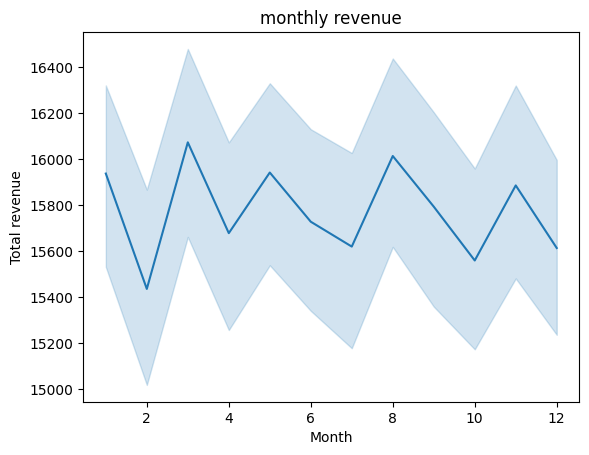

In [37]:
# Visualize monthly revenue using a line chart. using seaborn
sns.lineplot(data=data,x='Month',y='Total_Amount')
plt.xlabel('Month')
plt.ylabel('Total revenue')
plt.title('monthly revenue')
plt.show()

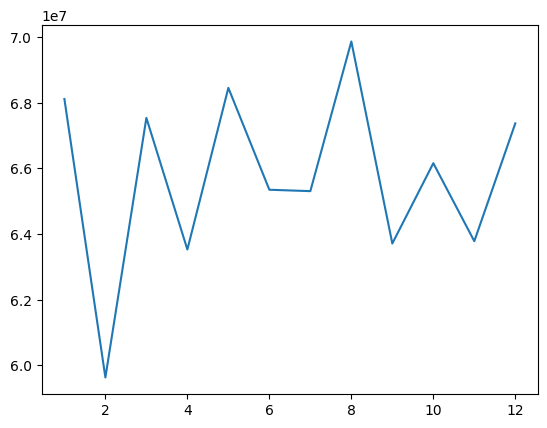

In [38]:
# Visualize monthly revenue using a line chart.-- using matplot

monthly_revenue = data.groupby('Month')['Total_Amount'].sum().sort_index()
plt.plot(monthly_revenue.index,monthly_revenue.values)


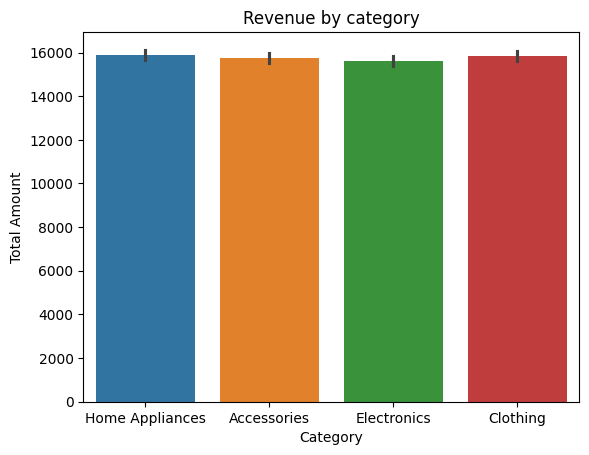

In [ ]:
# Create a bar chart for revenue by category.
sns.barplot(data=data,x='Category',y='Total_Amount',hue='Category')
plt.title('Revenue by category')
plt.ylabel('Total Amount')
plt.xlabel('Category')
plt.show()


In [59]:
# Plot the top 10 customers by total spending.
top_10_customers = data.groupby('Customer_ID')['Total_Amount'].sum().reset_index().head(10)
top_10_customers

,Customer_ID,Total_Amount
0,1000,93919.65
1,1001,112256.31
2,1002,95371.79
3,1003,51902.07
4,1004,72966.15
5,1005,216095.34
6,1006,68969.80
7,1007,58603.60
8,1008,14597.49
9,1009,50355.05


C:\Users\Gaurikant\AppData\Local\Temp\ipykernel_5164\173675785.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_customers,x='Customer_ID',y='Total_Amount',palette='coolwarm')


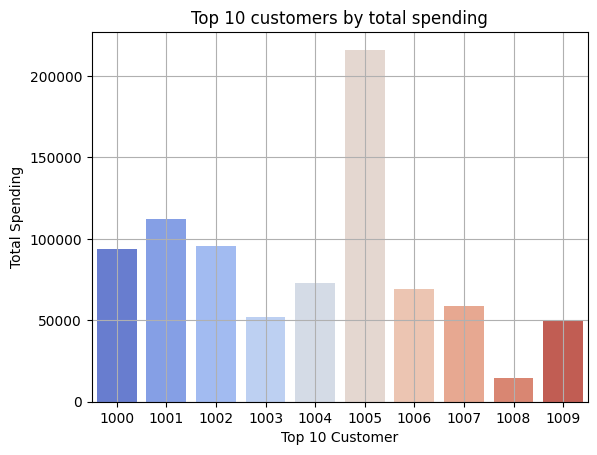

In [67]:

sns.barplot(data=top_10_customers,x='Customer_ID',y='Total_Amount',palette='coolwarm')
plt.title('Top 10 customers by total spending')
plt.xlabel('Top 10 Customer')
plt.ylabel('Total Spending')
plt.Figure(figsize=(11,6))
plt.grid(True)

plt.show()